<a href="https://colab.research.google.com/github/SURYABALA03/23CSE301-ML-24057/blob/main/ML6_Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
np.random.seed(42)

age = np.random.randint(18, 60, 100)

salary = np.random.randint(20000, 120000, 100)

purchased = ((age > 30) & (salary > 60000)).astype(int)

df = pd.DataFrame({
    "Age": age,
    "EstimatedSalary": salary,
    "Purchased": purchased
})

df.head()

,Age,EstimatedSalary,Purchased
0,56,28392,0
1,46,50535,0
2,32,98603,1
3,25,72256,0
4,38,109135,1


In [ ]:
df.head()

,Age,EstimatedSalary,Purchased
0,56,28392,0
1,46,50535,0
2,32,98603,1
3,25,72256,0
4,38,109135,1


In [ ]:
df.tail()

,Age,EstimatedSalary,Purchased
95,59,105616,1
96,56,113264,1
97,58,46736,0
98,45,114209,1
99,24,20854,0


In [ ]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (100, 3)


In [ ]:
df.columns

Index(['Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              100 non-null    int64
 1   EstimatedSalary  100 non-null    int64
 2   Purchased        100 non-null    int64
dtypes: int64(3)
memory usage: 2.5 KB


In [ ]:
df.isnull().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
df.describe()

,Age,EstimatedSalary,Purchased
count,100.000000,100.000000,100.000000
mean,37.910000,74788.380000,0.440000
std,12.219454,29763.175128,0.498888
min,18.000000,20206.000000,0.000000
25%,26.750000,46578.250000,0.000000
50%,38.000000,75932.000000,0.000000
75%,46.250000,100700.500000,1.000000
max,59.000000,118806.000000,1.000000


In [ ]:
df["Purchased"].value_counts()

,count
Purchased,
0,56
1,44


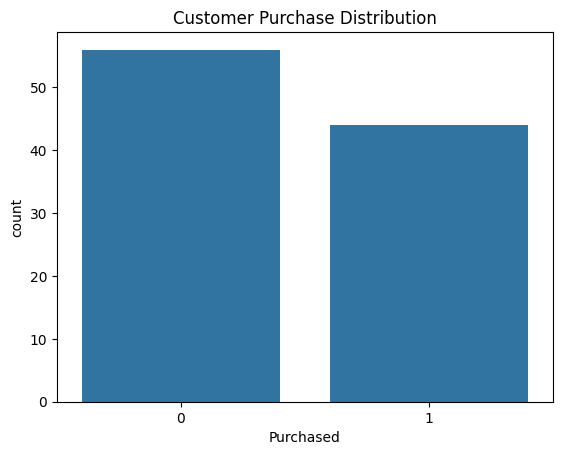

In [ ]:
sns.countplot(x="Purchased", data=df)

plt.title("Customer Purchase Distribution")

plt.show()

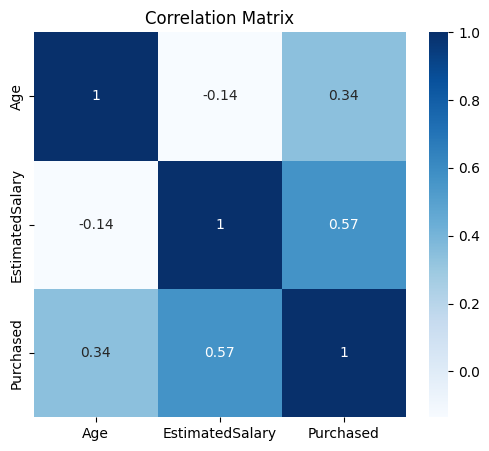

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Matrix")

plt.show()

In [ ]:
X = df[["Age","EstimatedSalary"]]

y = df["Purchased"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.95


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[11  0]
 [ 1  8]]


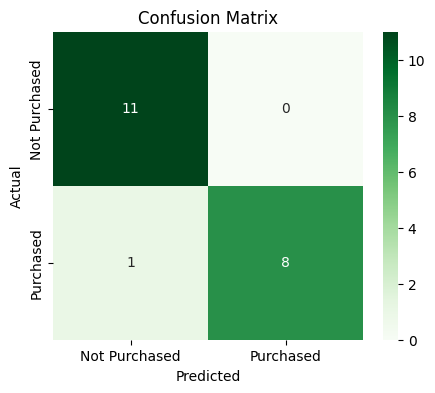

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Not Purchased','Purchased'],
            yticklabels=['Not Purchased','Purchased'])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      0.89      0.94         9

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



In [ ]:
new_customer = pd.DataFrame({
    "Age":[35],
    "EstimatedSalary":[70000]
})

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("The customer is likely to purchase the product.")
else:
    print("The customer is unlikely to purchase the product.")

The customer is unlikely to purchase the product.
